In [4]:
%load_ext autoreload
%autoreload 2

import numpy as np
from petra import make_catalog_mv_normal
from petra.flows import make_catalog_normalizing_flows
from petra.posterior_chain import PosteriorChain

import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
np.random.seed(0)
chain = np.zeros((10_000, 2))
chain_signal_1 = np.random.uniform(0, 1, 10000)
chain_signal_2 = np.random.uniform(0, 1, 10000)
chain[::2, 0] = chain_signal_1[::2]
chain[1::2, 0] = np.nan
chain[1::2, 1] = chain_signal_2[1::2]
chain[::2, 1] = np.nan
pc = PosteriorChain(chain, 2, 1)

In [18]:
chain

array([[0.5488135 ,        nan],
       [       nan, 0.18020271],
       [0.60276338,        nan],
       ...,
       [       nan, 0.44645576],
       [0.02378743,        nan],
       [       nan, 0.62588665]], shape=(10000, 2))

In [22]:
result = make_catalog_mv_normal(pc, max_num_sources=2, num_iterations=200)

Relabeling with multivariate normal distribution.

Sorting the posterior chain:
	Maximum number of iterations: 200
	Maximum number of source labels: 2

relabeling samples...


100%|██████████| 10000/10000 [00:00<00:00, 39848.90it/s]


updating parametric fit and probabilities in model...
Fewer than 8 values in source index 0. Appending normal distribution fit to all entries.
updating cost of assignment...
Iteration 1: Difference in cost of assignment is 1.5522542888748014 with total cost of 1.5522542888748014.
	Probabilities in model: [0.01 0.99]
relabeling samples...


100%|██████████| 10000/10000 [00:00<00:00, 36925.98it/s]


updating parametric fit and probabilities in model...
Fewer than 8 values in source index 0. Appending normal distribution fit to all entries.
updating cost of assignment...
Iteration 2: Difference in cost of assignment is -1.3498706703233376 with total cost of 0.20238361855146386.
	Probabilities in model: [0.01 0.99]
relabeling samples...


100%|██████████| 10000/10000 [00:00<00:00, 37173.76it/s]

updating parametric fit and probabilities in model...
Fewer than 8 values in source index 0. Appending normal distribution fit to all entries.
updating cost of assignment...
Iteration 3: Difference in cost of assignment is 0.0 with total cost of 0.20238361855146386.
	Probabilities in model: [0.01 0.99]
Stopped after 3 iterations because the cost didn't change from the previous iteration.
Fewer than 8 values in source index 0. Appending normal distribution fit to all entries.


In [ ]:
result = make_catalog_normalizing_flows(pc, max_num_sources=2, num_iterations=200)

In [ ]:
plt.bar(range(len(result)), result)
plt.xlabel("Source index")
plt.ylabel("Astrophysical probability")

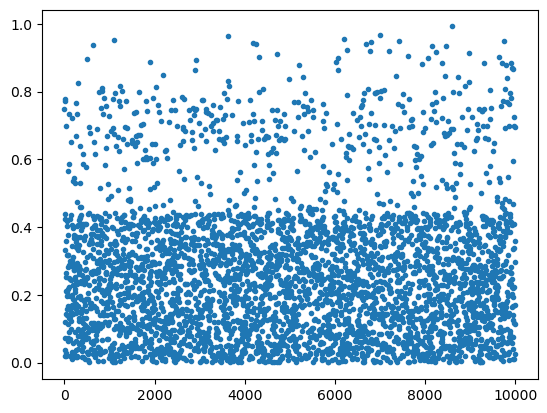

In [9]:
plt.plot(result[:, 1, 0], '.')

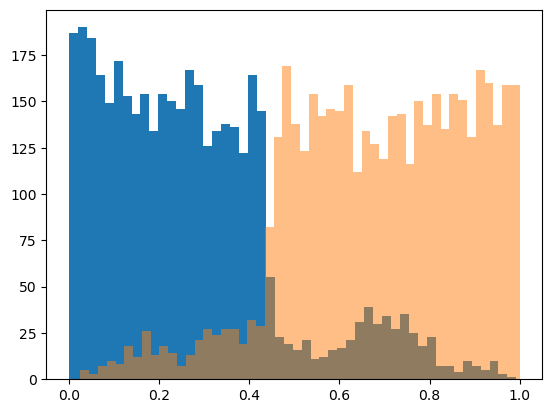

In [14]:
plt.hist(result[:, 1, 0], bins=50);
plt.hist(result[:, 0, 0], bins=50, alpha=0.5);
plt.show()